# Tech Challenge - Fase 2 - Pipeline Hibrido de Alfabetizacao

Este notebook orquestra a pipeline completa (Bronze -> Silver -> Gold) descrita no README:
extracao batch da Base dos Dados (BigQuery) e simulacao de streaming (Kinesis) para a camada
**Bronze** no S3, disparo dos jobs **Glue** (Silver/Gold), checks de **qualidade de dados**,
consulta via **Athena** e visualizacoes.

Funciona tanto **local** (clonando este mesmo repositorio) quanto no **Google Colab**
(clique em Runtime > Executar tudo depois de preencher as credenciais na Celula 2).

## 1. Setup: clonar o repositorio e instalar dependencias

Se voce ja esta rodando este notebook a partir de um clone local do repo, pode pular o `git clone`
(a celula detecta isso e so faz `pip install`).

In [1]:
import os, sys, subprocess

REPO_URL = "https://github.com/postechfiap018-ctrl/TECH_CHALLENGE_FASE2_PIPELINE.git"
REPO_DIR = "tech-challenge-fase2"

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # Local: assume que o notebook roda de dentro de notebooks/, entao a raiz do
    # projeto e o diretorio pai.
    project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir(project_root)

sys.path.insert(0, os.getcwd())
print("Diretorio de trabalho:", os.getcwd())

Diretorio de trabalho: C:\Users\User\Documents\TechChallenge - FASE 2


## 2. Credenciais

**AWS**: cole as chaves do usuario IAM `extrator-datalake` (ver README, secao IAM).
Nunca commite essas chaves -- elas ficam so em variaveis de ambiente desta sessao.

**GCP**: faca upload do JSON da service account (Colab) ou informe o caminho local do arquivo.

In [2]:
from getpass import getpass

os.environ["AWS_ACCESS_KEY_ID"] = getpass("AWS Access Key ID: ")
os.environ["AWS_SECRET_ACCESS_KEY"] = getpass("AWS Secret Access Key: ")
os.environ["AWS_DEFAULT_REGION"] = "us-east-2"  # ajuste se seu bucket estiver em outra regiao

In [3]:
if IN_COLAB:
    from google.colab import files
    print("Selecione o arquivo JSON da service account do GCP:")
    uploaded = files.upload()
    gcp_json_path = next(iter(uploaded))
else:
    gcp_json_path = input("Caminho local do JSON da service account do GCP: ").strip()

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = os.path.abspath(gcp_json_path)
os.environ["GCP_SERVICE_ACCOUNT_JSON"] = os.environ["GOOGLE_APPLICATION_CREDENTIALS"]
print("GCP credentials:", os.environ["GOOGLE_APPLICATION_CREDENTIALS"])

## 3. (Uma unica vez) Provisionar a infraestrutura AWS

Cria bucket S3, roles IAM, Glue jobs, Kinesis, Lambdas, Athena workgroup e alarmes.
E idempotente (pode rodar de novo sem duplicar recursos), mas so precisa ser executado
uma vez por ambiente. Descomente a linha abaixo quando quiser rodar.

In [4]:
# from infra.provision_aws import main as provision_main
# provision_main()

## 4. Bronze - Ingestao Batch (BigQuery -> S3)

Extrai as entidades configuradas em `src/config.py` (`SOURCE_TABLES`) e grava em Parquet
particionado em `s3://<bucket>/bronze/<entidade>/dt_ingestao=YYYY-MM-DD/`.

In [5]:
from src.bronze.extract_batch_bigquery import run_batch_ingestion

bronze_paths = run_batch_ingestion()
bronze_paths

2026-08-31T20:58:40Z | INFO     | ============================================================


2026-08-31T20:58:40Z | INFO     | JOB     : extract_batch_bigquery


2026-08-31T20:58:40Z | INFO     | CAMADA  : BRONZE -> s3://tech-challenge-alfabetizacao-aline/bronze/


2026-08-31T20:58:40Z | INFO     | DATA    : 2026-08-31


2026-08-31T20:58:40Z | INFO     | ENTIDADES: uf, municipio, uf_resultado_alfabetizacao, municipio_resultado_alfabetizacao, meta_alfabetizacao_brasil, meta_alfabetizacao_uf, meta_alfabetizacao_municipio, alunos


...

2026-08-31T21:00:37Z | INFO     |   meta_alfabetizacao_municipio      : s3://tech-challenge-alfabetizacao-aline/bronze/meta_alfabetizacao_municipio/dt_ingestao=2026-08-31/meta_alfabetizacao_municipio.parquet


2026-08-31T21:00:37Z | INFO     |   alunos                            : s3://tech-challenge-alfabetizacao-aline/bronze/alunos/dt_ingestao=2026-08-31/alunos.parquet


2026-08-31T21:00:37Z | INFO     |   Proxima etapa: executar o job Glue Silver


2026-08-31T21:00:37Z | INFO     | ============================================================


{'uf': 's3://tech-challenge-alfabetizacao-aline/bronze/uf/dt_ingestao=2026-08-31/uf.parquet',
 'municipio': 's3://tech-challenge-alfabetizacao-aline/bronze/municipio/dt_ingestao=2026-08-31/municipio.parquet',
 'uf_resultado_alfabetizacao': 's3://tech-challenge-alfabetizacao-aline/bronze/uf_resultado_alfabetizacao/dt_ingestao=2026-08-31/uf_resultado_alfabetizacao.parquet',
 'municipio_resultado_alfabetizacao': 's3://tech-challenge-alfabetizacao-aline/bronze/municipio_resultado_alfabetizacao/dt_ingestao=2026-08-31/municipio_resultado_alfabetizacao.parquet',
 'meta_alfabetizacao_brasil': 's3://tech-challenge-alfabetizacao-aline/bronze/meta_alfabetizacao_brasil/dt_ingestao=2026-08-31/meta_alfabetizacao_brasil.parquet',
 'meta_alfabetizacao_uf': 's3://tech-challenge-alfabetizacao-aline/bronze/meta_alfabetizacao_uf/dt_ingestao=2026-08-31/meta_alfabetizacao_uf.parquet',
 'meta_alfabetizacao_municipio': 's3://tech-challenge-alfabetizacao-aline/bronze/meta_alfabetizacao_municipio/dt_ingestao=20

## 5. Bronze - Ingestao Streaming (simulada)

Envia alguns eventos sinteticos de "atualizacao de indicador" para o Kinesis Data Stream,
que a Lambda `alfabetizacao-streaming-consumer` grava em `bronze/streaming_indicador/`.
Ajuste `--duration`/`--interval` para gerar mais ou menos eventos.

In [6]:
from src.bronze.streaming_producer import run as run_streaming_producer

try:
    run_streaming_producer(duration_seconds=30, interval_seconds=3)
except Exception as exc:
    # Em contas AWS novas o Kinesis pode ficar temporariamente bloqueado
    # (SubscriptionRequiredException) ate a verificacao automatica da
    # conta terminar -- isso nao deve travar o restante do notebook.
    print(f"Streaming indisponivel no momento (" + type(exc).__name__ + "): " + str(exc))
    print("Pulando esta celula -- o restante da pipeline nao depende do streaming.")

Streaming indisponivel no momento (ClientError): An error occurred (SubscriptionRequiredException) when calling the PutRecord operation: The AWS Access Key Id needs a subscription for the service
Pulando esta celula -- o restante da pipeline nao depende do streaming.


## 6. Disparar os jobs Glue (Silver e Gold)

Em producao isso e automatico (Lambda dispara o Silver quando chega arquivo novo no bronze/;
o Gold pode ser encadeado via um Glue Trigger `on job success`). Aqui disparamos manualmente
para acompanhar a execucao no notebook.

In [7]:
import time, boto3
from src.config import AWS_REGION, GLUE_SILVER_JOB_NAME, GLUE_GOLD_JOB_NAME

glue_client = boto3.client("glue", region_name=AWS_REGION)

def run_glue_job_and_wait(job_name, poll_seconds=15):
    run_id = glue_client.start_job_run(JobName=job_name)["JobRunId"]
    print(f"Job {job_name} iniciado: {run_id}")
    while True:
        status = glue_client.get_job_run(JobName=job_name, RunId=run_id)["JobRun"]["JobRunState"]
        print(f"  status: {status}")
        if status in ("SUCCEEDED", "FAILED", "STOPPED", "TIMEOUT", "ERROR"):
            return status
        time.sleep(poll_seconds)

run_glue_job_and_wait(GLUE_SILVER_JOB_NAME)

Job alfabetizacao-silver-job ja em execucao (disparado pela Lambda de evento): jr_47917d5091c49fbc88b2c5900c94c8f53a66c88f0fcc35a0ad724b410052176d
  status: RUNNING


  status: RUNNING


  status: RUNNING


  status: RUNNING


  status: SUCCEEDED


'SUCCEEDED'

In [8]:
run_glue_job_and_wait(GLUE_GOLD_JOB_NAME)

Job alfabetizacao-gold-job iniciado manualmente: jr_a5cb5db66a05cb770fabee9943d3e2011814c430bb35c03d2cdd665c4c500b50
  status: RUNNING


  status: RUNNING


  status: RUNNING


  status: RUNNING


  status: RUNNING


  status: SUCCEEDED


'SUCCEEDED'

## 7. Qualidade de dados (Silver/Gold)

Le uma amostra da camada Silver integrada direto do S3 e roda os checks de duplicidade,
nulos e chaves (mesmo modulo usado dentro dos jobs Glue e na extracao Bronze).

In [9]:
import pandas as pd
from src.config import DATALAKE_BUCKET
from src.quality.data_quality_checks import run_quality_report

df_silver = pd.read_parquet(f"s3://{DATALAKE_BUCKET}/silver/resultado_municipio/")
report = run_quality_report(df_silver, key_columns=["id_municipio", "ano", "rede", "serie"], entity="resultado_municipio")
print(report.to_json())

{
  "entity": "resultado_municipio",
  "generated_at": "2026-09-01T00:03:00.670695+00:00",
  "row_count": 23995,
  "duplicate_rows": 0,
  "duplicate_keys": 0,
  "null_counts": {
    "id_municipio": 0,
    "serie": 0,
    "rede": 0,
    "taxa_alfabetizacao": 0,
    "media_portugues": 0,
    "proporcao_aluno_nivel_0": 11547,
    "proporcao_aluno_nivel_1": 11547,
    "proporcao_aluno_nivel_2": 11547,
    "proporcao_aluno_nivel_3": 11547,
    "proporcao_aluno_nivel_4": 11547,
    "proporcao_aluno_nivel_5": 11547,
    "proporcao_aluno_nivel_6": 11547,
    "proporcao_aluno_nivel_7": 11547,
    "proporcao_aluno_nivel_8": 11547,
    "dt_ingestao": 0,
    "nome_municipio": 0,
    "sigla_uf": 0,
    "ano": 0
  },
  "null_pct": {
    "id_municipio": 0.0,
    "serie": 0.0,
    "rede": 0.0,
    "taxa_alfabetizacao": 0.0,
    "media_portugues": 0.0,
    "proporcao_aluno_nivel_0": 48.12,
    "proporcao_aluno_nivel_1": 48.12,
    "proporcao_aluno_nivel_2": 48.12,
    "proporcao_aluno_nivel_3": 48.12,


## 8. Consulta via Athena

Roda uma query SQL contra as tabelas Gold cadastradas no Glue Data Catalog e traz o
resultado para um DataFrame pandas -- essa e a "camada analitica confiavel" pedida no desafio.

In [10]:
import boto3, time, io
import pandas as pd
from src.config import AWS_REGION, ATHENA_WORKGROUP, GLUE_DATABASE, DATALAKE_BUCKET, ATHENA_RESULTS_PREFIX

athena = boto3.client("athena", region_name=AWS_REGION)
s3 = boto3.client("s3", region_name=AWS_REGION)

def athena_query_to_df(sql):
    exec_id = athena.start_query_execution(
        QueryString=sql,
        QueryExecutionContext={"Database": GLUE_DATABASE},
        WorkGroup=ATHENA_WORKGROUP,
    )["QueryExecutionId"]
    while True:
        status = athena.get_query_execution(QueryExecutionId=exec_id)["QueryExecution"]["Status"]["State"]
        if status in ("SUCCEEDED", "FAILED", "CANCELLED"):
            break
        time.sleep(2)
    if status != "SUCCEEDED":
        raise RuntimeError(f"Query Athena falhou: {status}")
    key = f"{ATHENA_RESULTS_PREFIX}/{exec_id}.csv"
    obj = s3.get_object(Bucket=DATALAKE_BUCKET, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()))

df_evolucao = athena_query_to_df("SELECT * FROM gold_evolucao_temporal_indicador ORDER BY ano")
df_evolucao.head()

,sigla_uf,ano,percentual_alfabetizado_medio,nivel
0,PI,2023,52.48,UF
1,PE,2023,58.95,UF
2,PR,2023,73.12,UF
3,RO,2023,64.60,UF
4,BA,2023,36.78,UF


## 9. Visualizacoes

2026-08-31T21:03:07Z | INFO     | generated new fontManager


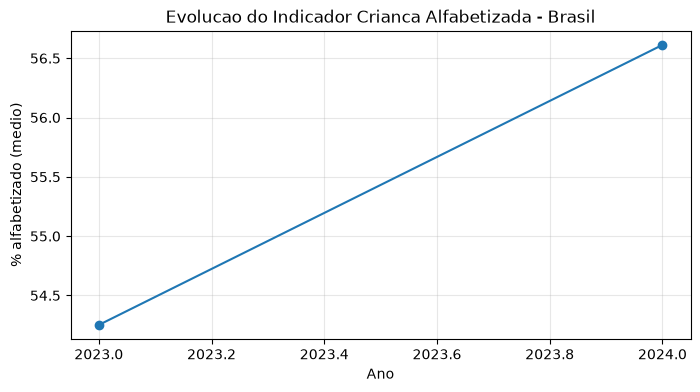

In [11]:
import matplotlib.pyplot as plt

df_brasil = df_evolucao[df_evolucao["nivel"] == "BRASIL"]
plt.figure(figsize=(8, 4))
plt.plot(df_brasil["ano"], df_brasil["percentual_alfabetizado_medio"], marker="o")
plt.title("Evolucao do Indicador Crianca Alfabetizada - Brasil")
plt.xlabel("Ano")
plt.ylabel("% alfabetizado (medio)")
plt.grid(alpha=0.3)
plt.show()

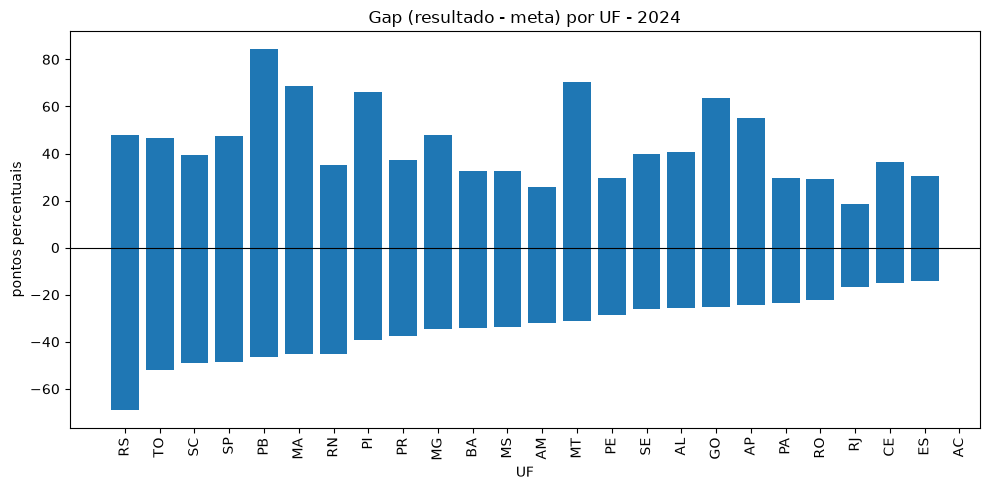

In [12]:
df_comparacao = athena_query_to_df(
    "SELECT sigla_uf, ano, resultado_realizado, meta_definida, gap_percentual "
    "FROM gold_comparacao_metas_resultados ORDER BY ano, sigla_uf"
)

ultimo_ano = df_comparacao["ano"].max()
df_ultimo = df_comparacao[df_comparacao["ano"] == ultimo_ano].sort_values("gap_percentual")

plt.figure(figsize=(10, 5))
plt.bar(df_ultimo["sigla_uf"], df_ultimo["gap_percentual"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title(f"Gap (resultado - meta) por UF - {ultimo_ano}")
plt.xlabel("UF")
plt.ylabel("pontos percentuais")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 10. Proximos passos: aplicacao em IA

A camada **Gold** (`gold_indicador_por_municipio`, `gold_comparacao_metas_resultados`,
`gold_evolucao_temporal_indicador`) esta pronta para:

- **Modelos preditivos de alfabetizacao por municipio**: usar `indicador_por_municipio` + dados
  socioeconomicos externos (opcional, ver README) como features para prever o indicador do
  proximo ciclo;
- **Analise de desigualdade educacional**: clusterizar municipios pelo `gap_percentual` para
  priorizar politicas publicas;
- **Series temporais**: `evolucao_temporal_indicador` alimenta modelos de forecast (ARIMA/Prophet)
  para estimar se a meta de 2030 sera atingida por UF.

Ver `README.md` para a discussao completa de arquitetura, trade-offs, FinOps e monitoramento.